# 🛒 Módulo 7: Regras de Associação e Sequências

## Objetivos de Aprendizagem

Ao final deste módulo, você será capaz de:

1. **Compreender o algoritmo Apriori** — gerar itemsets frequentes e extrair regras de associação com suporte e confiança mínimos
2. **Calcular e interpretar as métricas** — suporte, confiança, lift e conviction para avaliar a força e utilidade de uma regra
3. **Identificar co-ocorrências em dados transacionais** — detectar padrões de compra conjunta em dados de varejo
4. **Visualizar regras de associação** — construir heatmaps de co-ocorrência, scatter plots e gráficos de lift
5. **Entender padrões sequenciais** — aplicar o conceito de sequências temporais para recomendações e análise de comportamento

## Teoria: Regras de Associação

### Métricas Fundamentais

**Suporte** — frequência com que o conjunto de itens aparece nas transações:

$$\text{suporte}(A \Rightarrow B) = \frac{|A \cup B|}{N}$$

**Confiança** — probabilidade de B ocorrer dado que A ocorreu:

$$\text{confiança}(A \Rightarrow B) = \frac{|A \cup B|}{|A|} = P(B|A)$$

**Lift** — quanto a regra melhora sobre a chance aleatória:

$$\text{lift}(A \Rightarrow B) = \frac{P(A \cup B)}{P(A) \cdot P(B)}$$

- **Lift = 1**: A e B são independentes (regra inútil)
- **Lift > 1**: associação positiva — A e B ocorrem juntos mais que o esperado
- **Lift < 1**: associação negativa — A e B se evitam

**Conviction** — mede a dependência direcional da regra:

$$\text{conviction}(A \Rightarrow B) = \frac{1 - \text{suporte}(B)}{1 - \text{confiança}(A \Rightarrow B)}$$

- Conviction → ∞ : regra perfeita (A sempre implica B)
- Conviction = 1 : regra aleatória (A e B independentes)

---

### Limiares Recomendados na Prática

| Parâmetro | Limiar Mínimo | Observação |
|---|---|---|
| **Suporte** | > 0.01 (1%) | Muito abaixo = ruído estatístico |
| **Confiança** | > 0.30 (30%) | Abaixo disso a regra é pouco confiável |
| **Lift** | > 1.20 | Lift próximo de 1 = sem ganho real |
| **Conviction** | > 1.10 | Indica dependência direcional útil |

> **Atenção:** Em datasets com muitos produtos (ex: varejo de moda, e-commerce), o suporte mínimo pode ser reduzido para 0.001 (0.1%), pois cada produto individualmente aparece com pouca frequência.

---

### O Algoritmo Apriori

O Apriori utiliza a propriedade anti-monotônica do suporte:

> **Princípio Apriori:** Se um conjunto de itens é infrequente, todos os seus superconjuntos também são infrequentes.

**Passos:**
1. Encontrar todos os itemsets de tamanho 1 com suporte ≥ suporte_min
2. Combinar itemsets frequentes para gerar candidatos de tamanho k+1
3. Podar candidatos com subconjuntos infrequentes (poda Apriori)
4. Calcular suporte dos candidatos restantes
5. Repetir até não haver mais itemsets frequentes
6. Gerar regras a partir dos itemsets frequentes com confiança ≥ confiança_min

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

produtos = ['Arroz', 'Feijão', 'Macarrão', 'Azeite', 'Frango', 'Carne_Bovina',
            'Leite', 'Queijo', 'Iogurte', 'Pão', 'Manteiga', 'Café', 'Suco',
            'Cerveja', 'Refrigerante', 'Detergente', 'Sabão', 'Papel_Higienico',
            'Shampoo', 'Chocolate']

# Criar regras de co-ocorrência realistas
coocorrencias = {
    'Arroz': ['Feijão', 'Frango'], 'Feijão': ['Arroz', 'Frango'],
    'Leite': ['Pão', 'Manteiga', 'Queijo', 'Café'], 'Pão': ['Manteiga', 'Leite'],
    'Cerveja': ['Frango', 'Chocolate'], 'Queijo': ['Iogurte', 'Leite'],
    'Detergente': ['Sabão', 'Papel_Higienico'], 'Shampoo': ['Sabão'],
}

transacoes = []
for _ in range(600):
    n_itens = np.random.poisson(4) + 1
    base = np.random.choice(produtos, min(n_itens, 8), replace=False).tolist()
    for item in base.copy():
        if item in coocorrencias and np.random.rand() < 0.6:
            for assoc in coocorrencias[item]:
                if assoc not in base and np.random.rand() < 0.5:
                    base.append(assoc)
    transacoes.append(list(set(base[:10])))

print(f"Total de transações: {len(transacoes)}")
print(f"\nExemplos de transações:")
for i, t in enumerate(transacoes[:5]):
    print(f"  Compra {i+1}: {sorted(t)}")

# Estatísticas básicas
tamanhos = [len(t) for t in transacoes]
print(f"\nEstatísticas do carrinho:")
print(f"  Tamanho médio: {np.mean(tamanhos):.1f} itens")
print(f"  Tamanho mínimo: {min(tamanhos)} | máximo: {max(tamanhos)}")

# Frequência dos produtos
freq_prod = pd.Series([item for t in transacoes for item in t]).value_counts()
print(f"\nTop 10 produtos mais frequentes:")
print(freq_prod.head(10).to_string())

Total de transações: 600

Exemplos de transações:
  Compra 1: ['Arroz', 'Café', 'Iogurte', 'Leite', 'Manteiga', 'Pão', 'Queijo', 'Refrigerante', 'Suco']
  Compra 2: ['Arroz', 'Carne_Bovina', 'Feijão', 'Frango', 'Shampoo']
  Compra 3: ['Arroz', 'Carne_Bovina', 'Frango', 'Macarrão', 'Refrigerante', 'Shampoo']
  Compra 4: ['Café', 'Carne_Bovina', 'Feijão', 'Refrigerante']
  Compra 5: ['Arroz', 'Carne_Bovina', 'Chocolate', 'Feijão', 'Frango', 'Manteiga', 'Papel_Higienico', 'Queijo', 'Suco']

Estatísticas do carrinho:
  Tamanho médio: 5.7 itens
  Tamanho mínimo: 1 | máximo: 10

Top 10 produtos mais frequentes:
Frango             259
Leite              224
Sabão              209
Manteiga           198
Queijo             190
Iogurte            182
Pão                180
Feijão             177
Arroz              174
Papel_Higienico    161


In [2]:
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    
    te = TransactionEncoder()
    te_array = te.fit_transform(transacoes)
    df_trans = pd.DataFrame(te_array, columns=te.columns_)
    
    itemsets_freq = apriori(df_trans, min_support=0.05, use_colnames=True)
    regras = association_rules(itemsets_freq, metric='lift', min_threshold=1.2)
    regras = regras.sort_values('lift', ascending=False)
    
    print(f"Itemsets frequentes (sup >= 5%): {len(itemsets_freq)}")
    print(f"Regras de associação (lift >= 1.2): {len(regras)}")
    print("\nTop 10 Regras por Lift:")
    display(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).round(3))

except ImportError:
    print("mlxtend não instalado. Execute: pip install mlxtend")
    print("\nImplementação manual do Apriori:")
    from itertools import combinations
    
    def calcular_suporte(transacoes, itemset):
        return sum(1 for t in transacoes if itemset.issubset(set(t))) / len(transacoes)
    
    min_sup = 0.05
    itens_unicos = list(set(item for t in transacoes for item in t))
    itemsets_1 = [frozenset([item]) for item in itens_unicos 
                   if calcular_suporte(transacoes, frozenset([item])) >= min_sup]
    
    print(f"Itens frequentes (sup >= {min_sup:.0%}): {len(itemsets_1)} de {len(itens_unicos)}")
    top_items = sorted([(s, calcular_suporte(transacoes, s)) for s in itemsets_1], 
                        key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 itens por suporte:")
    for item, sup in top_items:
        print(f"  {list(item)[0]}: {sup:.3f}")
    
    # Pares frequentes
    print("\nCalculando pares frequentes...")
    pares = []
    for a, b in combinations([list(s)[0] for s in itemsets_1], 2):
        sup = calcular_suporte(transacoes, frozenset([a, b]))
        if sup >= min_sup:
            conf_ab = sup / calcular_suporte(transacoes, frozenset([a]))
            sup_b = calcular_suporte(transacoes, frozenset([b]))
            lift = conf_ab / sup_b if sup_b > 0 else 0
            if lift >= 1.2:
                pares.append({'A': a, 'B': b, 'Suporte': sup, 'Confiança': conf_ab, 'Lift': lift})
    
    regras_manuais = pd.DataFrame(pares).sort_values('Lift', ascending=False)
    print(f"Regras com lift >= 1.2: {len(regras_manuais)}")
    display(regras_manuais.head(10).round(3))
    regras = None  # flag para visualização

Itemsets frequentes (sup >= 5%): 266
Regras de associação (lift >= 1.2): 328

Top 10 Regras por Lift:


,antecedents,consequents,support,confidence,lift
325,(Arroz),"(Feijão, Leite, Frango)",0.050,0.172,2.586
318,"(Feijão, Leite, Frango)",(Arroz),0.050,0.750,2.586
323,"(Feijão, Leite)","(Arroz, Frango)",0.050,0.462,2.429
320,"(Arroz, Frango)","(Feijão, Leite)",0.050,0.263,2.429
319,"(Arroz, Leite)","(Feijão, Frango)",0.050,0.441,2.363
324,"(Feijão, Frango)","(Arroz, Leite)",0.050,0.268,2.363
166,"(Chocolate, Frango)",(Cerveja),0.065,0.582,2.344
167,(Cerveja),"(Chocolate, Frango)",0.065,0.262,2.344
55,(Arroz),"(Feijão, Frango)",0.127,0.437,2.340
54,"(Feijão, Frango)",(Arroz),0.127,0.679,2.340


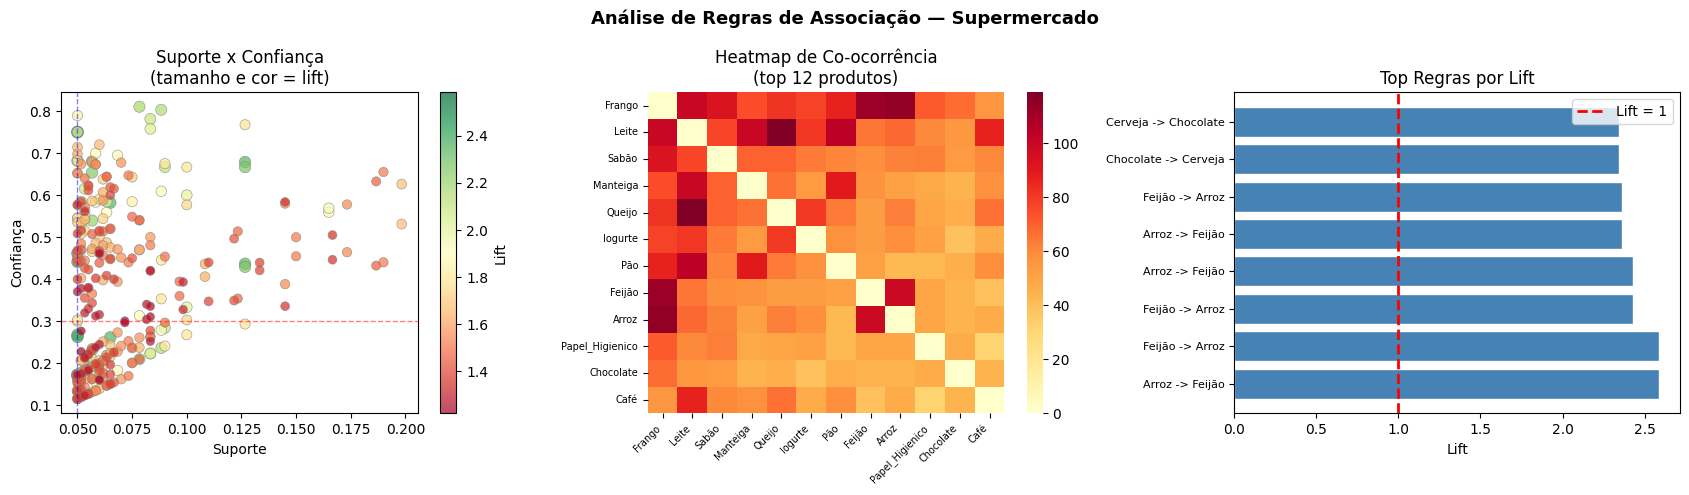

In [3]:
from itertools import combinations

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Análise de Regras de Associação — Supermercado', fontsize=13, fontweight='bold')

try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    
    te = TransactionEncoder()
    te_array = te.fit_transform(transacoes)
    df_trans = pd.DataFrame(te_array, columns=te.columns_)
    itemsets_freq = apriori(df_trans, min_support=0.05, use_colnames=True)
    regras = association_rules(itemsets_freq, metric='lift', min_threshold=1.2)
    regras = regras.sort_values('lift', ascending=False)
    
    # Scatter: suporte vs confiança, tamanho = lift
    sc = axes[0].scatter(regras['support'], regras['confidence'], 
                          s=regras['lift']*30, c=regras['lift'], cmap='RdYlGn',
                          alpha=0.7, edgecolors='gray', lw=0.5)
    plt.colorbar(sc, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Suporte'); axes[0].set_ylabel('Confiança')
    axes[0].set_title('Suporte x Confiança\n(tamanho e cor = lift)')
    axes[0].axhline(0.3, color='red', lw=1, linestyle='--', alpha=0.5)
    axes[0].axvline(0.05, color='blue', lw=1, linestyle='--', alpha=0.5)
    
    # Heatmap de coocorrência (top 12 produtos)
    top_prod = pd.Series([item for t in transacoes for item in t]).value_counts().head(12).index.tolist()
    cooc = pd.DataFrame(0, index=top_prod, columns=top_prod)
    for t in transacoes:
        t_top = [p for p in t if p in top_prod]
        for a, b in combinations(t_top, 2):
            cooc.loc[a, b] += 1
            cooc.loc[b, a] += 1
    np.fill_diagonal(cooc.values, 0)
    sns.heatmap(cooc, ax=axes[1], cmap='YlOrRd', annot=False, 
                xticklabels=True, yticklabels=True)
    axes[1].set_title('Heatmap de Co-ocorrência\n(top 12 produtos)')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
    plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=7)
    
    # Top regras por lift
    top_regras = regras.head(8)
    labels = [f"{list(r['antecedents'])[0]} -> {list(r['consequents'])[0]}" 
               for _, r in top_regras.iterrows()]
    axes[2].barh(range(len(top_regras)), top_regras['lift'].values, color='steelblue', edgecolor='white')
    axes[2].set_yticks(range(len(top_regras)))
    axes[2].set_yticklabels(labels, fontsize=8)
    axes[2].axvline(1, color='red', lw=2, linestyle='--', label='Lift = 1')
    axes[2].set_xlabel('Lift'); axes[2].set_title('Top Regras por Lift')
    axes[2].legend()
    
except Exception:
    # Fallback: frequência dos produtos
    freq = pd.Series([item for t in transacoes for item in t]).value_counts()
    axes[0].barh(freq.index[:15], freq.values[:15], color='steelblue')
    axes[0].set_title('Frequência dos Produtos')
    axes[0].set_xlabel('Número de Transações')
    
    # Heatmap de coocorrência
    top_prod = freq.head(12).index.tolist()
    cooc_matrix = pd.DataFrame(0, index=top_prod, columns=top_prod)
    for t in transacoes:
        t_top = [p for p in t if p in top_prod]
        for a, b in combinations(t_top, 2):
            cooc_matrix.loc[a, b] += 1
            cooc_matrix.loc[b, a] += 1
    np.fill_diagonal(cooc_matrix.values, 0)
    sns.heatmap(cooc_matrix, ax=axes[1], cmap='YlOrRd')
    axes[1].set_title('Heatmap de Co-ocorrência')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=7)
    plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=7)
    
    axes[2].text(0.5, 0.5, 'Instale mlxtend\npip install mlxtend\npara regras Apriori', 
                  transform=axes[2].transAxes, ha='center', va='center', fontsize=12)
    axes[2].axis('off')

plt.tight_layout()
plt.savefig('../imagens/07_associacao.png', dpi=150, bbox_inches='tight')
plt.show()

## Aplicações Reais de Regras de Associação

### Casos de Uso Clássicos

**Varejo e E-commerce:**
- Amazon: "Quem comprou X também comprou Y" — o sistema de recomendação mais famoso do mundo usa variantes de associação
- Supermercados: disposição de produtos nas prateleiras (ex: fraldas perto de cerveja — um insight famoso do Walmart)
- Cross-selling: oferta de produtos complementares no checkout

**Saúde e Medicina:**
- Identificar comorbidades frequentes — pacientes com diabetes e hipertensão frequentemente apresentam também...
- Padrões de prescrição médica — quais medicamentos são prescritos juntos?
- Análise de prontuários para descoberta de diagnósticos relacionados

**Segurança e Fraude:**
- Detecção de padrões de transações suspeitas — certas sequências de operações indicam lavagem de dinheiro
- Análise de logs de segurança — sequências de eventos que precedem ataques

---

### Padrões Sequenciais

Regras de associação tradicionais ignoram a **ordem temporal** das transações. Análise de sequências resolve isso:

**Exemplo:**
```
Cliente A: Semana 1 → {Frango} → Semana 2 → {Molho de Tomate, Macarrão}
```

Isso sugere que comprar frango **precede** comprar ingredientes para molho.

**Algoritmos de Sequências:**
- **GSP (Generalized Sequential Patterns)**: extensão do Apriori para sequências
- **PrefixSpan**: mais eficiente, usa projeção de banco de dados
- **SPADE**: vertical data mining para sequências

**Métricas adaptadas:**
- **Suporte sequencial**: proporção de clientes que seguiram a sequência A → B
- **Confiança sequencial**: dado que o cliente comprou A, qual a probabilidade de comprar B depois?

---

### Limitações e Cuidados

| Limitação | Solução |
|---|---|
| Muitas regras geradas (poluição de regras) | Filtrar por lift mínimo e usar convicção |
| Correlação ≠ Causalidade | Validar com testes A/B antes de agir |
| Dados esparsos em grandes catálogos | Reduzir suporte mínimo ou usar embedding |
| Regras óbvias (pão → manteiga) | Usar métricas adicionais como surpresa ou utilidade |

## Resumo e Exercícios

### Resumo do Módulo

Neste módulo aprendemos:
- **Regras de Associação** descobrem padrões de co-ocorrência em dados transacionais
- **Apriori** usa a propriedade anti-monotônica para podar o espaço de busca eficientemente
- **Suporte** mede frequência, **Confiança** mede implicação condicional, **Lift** mede ganho sobre o acaso
- **Lift > 1** é o critério mais importante para selecionar regras úteis
- Regras de **sequência** adicionam a dimensão temporal, capturando padrões de comportamento ao longo do tempo

---

### Exercícios Propostos

**Exercício 1 — Exploração de Parâmetros**
Altere o suporte mínimo de 5% para 2% e para 10%. Como isso afeta o número de regras geradas? Qual é o trade-off?

**Exercício 2 — Análise de Conviction**
Calcule a conviction das top 10 regras por lift. Existe alguma regra com lift alto mas conviction baixo? O que isso significa?

**Exercício 3 — Regras Negativas**
Identifique pares de produtos com lift < 0.8 (associação negativa). Esses pares dificilmente são comprados juntos — como isso pode ser útil para o layout da loja?

**Exercício 4 — Segmentação por Cluster de Compras**
Usando a matriz de transações criada, aplique K-means para agrupar clientes por padrão de compras. Quais grupos de clientes emergem? Gere regras de associação separadas para cada segmento.

**Exercício 5 — Dataset Real**
Baixe o dataset "Online Retail" do UCI Machine Learning Repository e aplique o pipeline completo: limpeza dos dados → codificação → Apriori → análise das top 20 regras. Quais insights de negócio você encontraria?